In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv("vgsales.csv")

## Subplots

Subplots allow you to **put multiple plots inside one figure**.

Instead of opening many figures like this:

```
Plot 1 window
Plot 2 window
Plot 3 window
```

You get:

```
[ Plot 1 | Plot 2 ]
```

inside **one figure**.

___

### Method 1 — `plt.subplot()` Syntax

#### Syntax

```python
plt.subplot(rows, columns, position)
```

Meaning:

```
rows → number of rows in grid
columns → number of columns in grid
position → which plot you are drawing
```

---

In [4]:
# Suppose if we want to compare the trend of eu sales and jp sales together per year

eu_sales = df.groupby("Year")["EU_Sales"].sum().sort_values(ascending=False)
jp_sales = df.groupby("Year")["JP_Sales"].sum().sort_values(ascending=False)

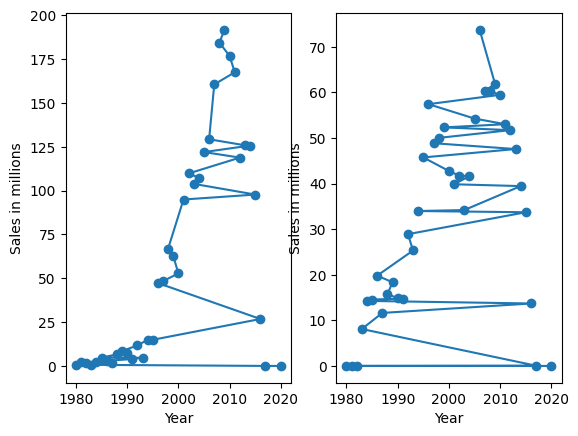

In [17]:
plt.Figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(eu_sales, marker="o")
plt.xlabel("Year")
plt.ylabel("Sales in millions")

plt.subplot(1,2,2)
plt.plot(jp_sales, marker="o")
plt.xlabel("Year")
plt.ylabel("Sales in millions")
plt.show()

#### Visual Structure

```
plt.figure()

 ├── subplot(1,2,1) → left plot
 │        histogram
 │
 └── subplot(1,2,2) → right plot
          histogram
```

---

#### Important Rule

Every time you call:

```python
plt.subplot()
```

you **activate a new plotting area**.

The next plot command goes inside that area.

---

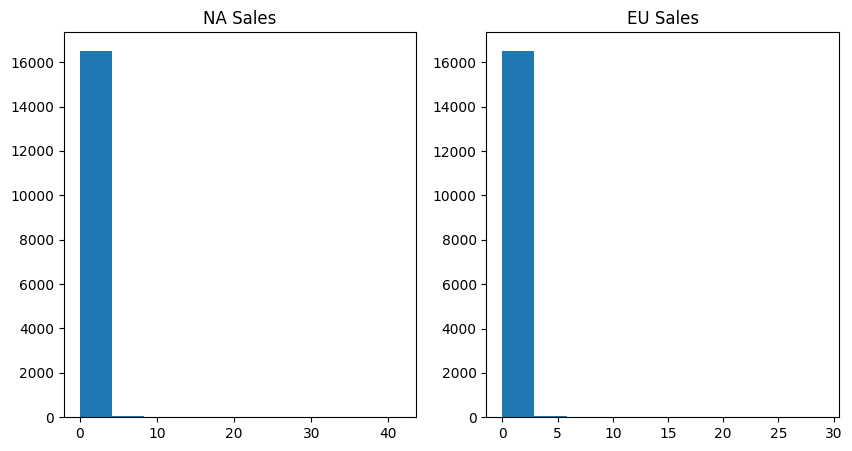

In [12]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(df["NA_Sales"])
plt.title("NA Sales")

plt.subplot(1,2,2)
plt.hist(df["EU_Sales"])
plt.title("EU Sales")

plt.show()

#### Modern Method — `plt.subplots()`

#### Syntax

```python
fig, ax = plt.subplots(rows, columns)
```

Meaning:

* **fig** → the whole figure (canvas)
* **ax** → the axes (individual plots)

Think of it like this:

```
Figure
 ├── Axes (Plot 1)
 ├── Axes (Plot 2)
 └── Axes (Plot 3)
```

---

(<Figure size 640x480 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))


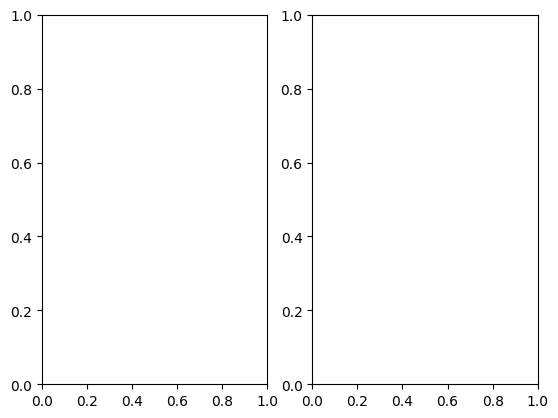

In [ ]:
print(plt.subplots(1,2))
# Understand what it returns -> a figure size and an array if you can see

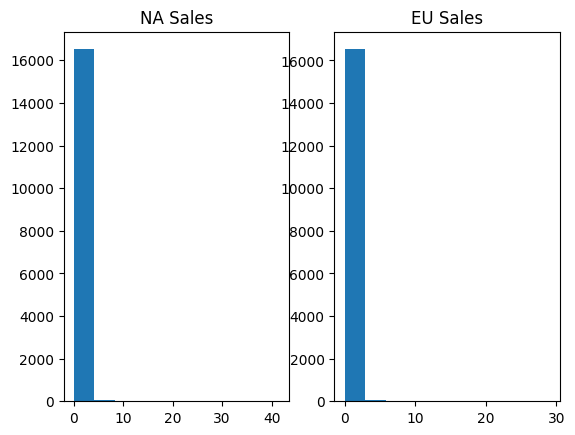

In [ ]:
fig, ax = plt.subplots(1, 2)

ax[0].hist(df["NA_Sales"])
ax[0].set_title("NA Sales")

ax[1].hist(df["EU_Sales"])
ax[1].set_title("EU Sales")

plt.show()

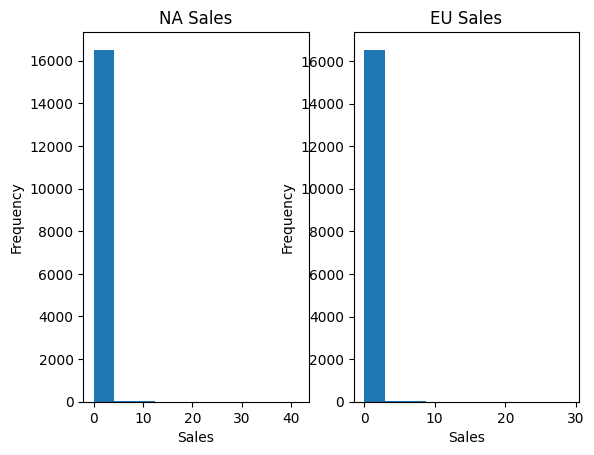

In [ ]:
fig, ax = plt.subplots(1,2)

ax[0].hist(df["NA_Sales"])
ax[0].set_title("NA Sales")
ax[0].set_xlabel("Sales")
ax[0].set_ylabel("Frequency")

ax[1].hist(df["EU_Sales"])
ax[1].set_title("EU Sales")
ax[1].set_xlabel("Sales")
ax[1].set_ylabel("Frequency")

plt.show()

## Avoid the overlap

### Understanding the Syntax

#### This line

```python
fig, ax = plt.subplots(1, 2)
```

creates:

```
[ ax[0] ] [ ax[1] ]
```

So you access plots using:

```
ax[0]
ax[1]
```

---

#### Adding Labels

With `subplots()` we don't use `plt.title()`.

Instead we use:

```python
ax[i].set_title()
ax[i].set_xlabel()
ax[i].set_ylabel()
```

## Multiple Lines in One Plot


In [22]:
# Step 1 — Aggregate Data by Year

sales_by_year = df.groupby("Year")[["NA_Sales", "EU_Sales"]].sum()

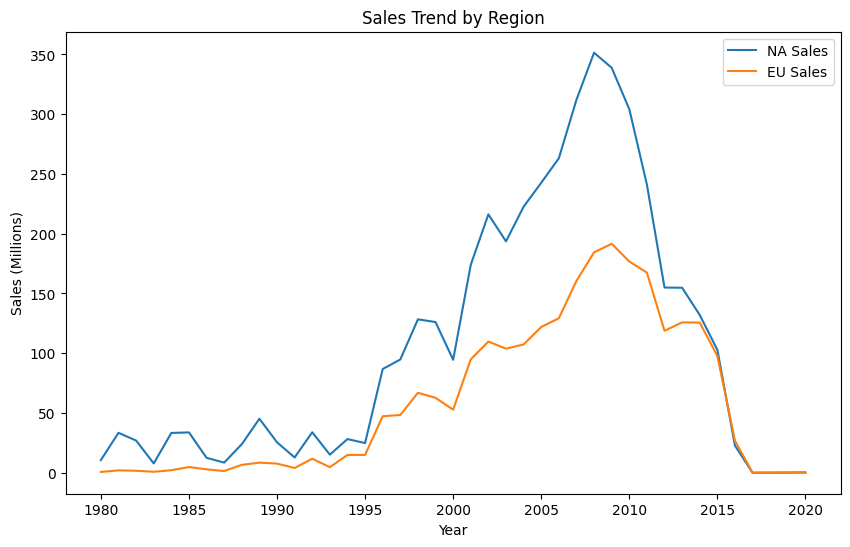

In [23]:
# Plot both the lines

plt.figure(figsize=(10,6))

plt.plot(sales_by_year.index, sales_by_year["NA_Sales"], label="NA Sales")
plt.plot(sales_by_year.index, sales_by_year["EU_Sales"], label="EU Sales")

plt.title("Sales Trend by Region")
plt.xlabel("Year")
plt.ylabel("Sales (Millions)")

plt.legend()

plt.show()

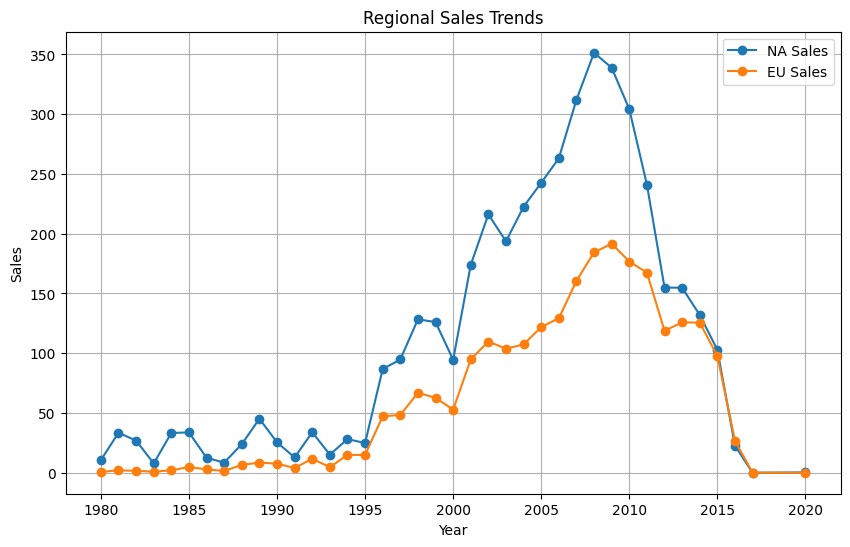

In [26]:
# Add Markers and grid for more cleaner understanding

plt.figure(figsize=(10,6))

plt.plot(sales_by_year.index,
         sales_by_year["NA_Sales"],
         marker='o',
         label="NA Sales")

plt.plot(sales_by_year.index,
         sales_by_year["EU_Sales"],
         marker="o",
         label="EU Sales")

plt.title("Regional Sales Trends")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.legend()
plt.grid()

plt.show()

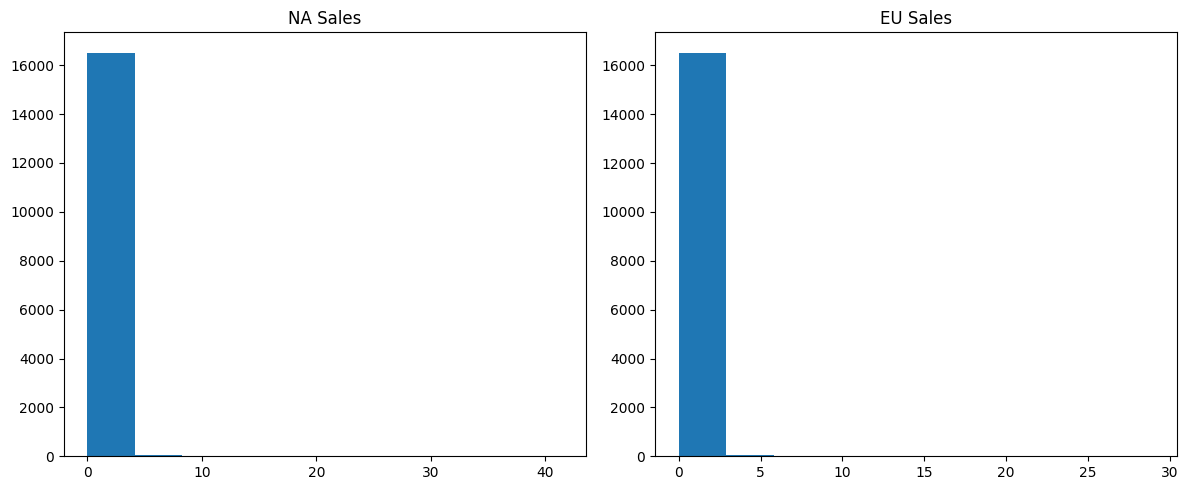

In [27]:
""" 
We face the problems of,
Titles overlapping
Axes touching each other
Labels cut off

for this use plt.tight_layout()
"""

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].hist(df["NA_Sales"])
ax[0].set_title("NA Sales")

ax[1].hist(df["EU_Sales"])
ax[1].set_title("EU Sales")

plt.tight_layout()

plt.show()